# Data-Driven Analysis of Retail Discount Strategy

**Business Problem:**

In this competitive world we often see companies providing discounts in order to attract customers and increase sales. However, excessive or uncontrolled discounting can silently vanish the company's profit margins & give birth to a situation where higher revenues does not translate into sustainable profitablility.
Live examples : Doodhwala, Shuttl

This project investigates a retail sales dataset to understand whether the company’s pricing strategy is helping or hurting overall profitability.

The key business question explored in this analysis is:

“Do discount-driven sales actually improve business performance, or they destroy profitability?”

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [ ]:
# df = pd.read_csv(r"file_path")
df = pd.read_csv(<YOUR_FILE_PATH>)
df.head()

,Product_ID,Sale_Date,Sales_Rep,Region,Sales_Amount,Quantity_Sold,Product_Category,Unit_Cost,Unit_Price,Customer_Type,Discount,Payment_Method,Sales_Channel,Region_and_Sales_Rep
0,1052,2023-02-03,Bob,North,"5,053.97",18,Furniture,152.75,267.22,Returning,0.09,Cash,Online,North-Bob
1,1093,2023-04-21,Bob,West,"4,384.02",17,Furniture,"3,816.39","4,209.44",Returning,0.11,Cash,Retail,West-Bob
2,1015,2023-09-21,David,South,"4,631.23",30,Food,261.56,371.40,Returning,0.20,Bank Transfer,Retail,South-David
3,1072,2023-08-24,Bob,South,"2,167.94",39,Clothing,"4,330.03","4,467.75",New,0.02,Credit Card,Retail,South-Bob
4,1061,2023-03-24,Charlie,East,"3,750.20",13,Electronics,637.37,692.71,New,0.08,Credit Card,Online,East-Charlie


In [11]:
# Quick structural check
df.shape

(1000, 14)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Product_ID            1000 non-null   int64  
 1   Sale_Date             1000 non-null   object 
 2   Sales_Rep             1000 non-null   object 
 3   Region                1000 non-null   object 
 4   Sales_Amount          1000 non-null   float64
 5   Quantity_Sold         1000 non-null   int64  
 6   Product_Category      1000 non-null   object 
 7   Unit_Cost             1000 non-null   float64
 8   Unit_Price            1000 non-null   float64
 9   Customer_Type         1000 non-null   object 
 10  Discount              1000 non-null   float64
 11  Payment_Method        1000 non-null   object 
 12  Sales_Channel         1000 non-null   object 
 13  Region_and_Sales_Rep  1000 non-null   object 
dtypes: float64(4), int64(2), object(8)
memory usage: 109.5+ KB


In [13]:
df.describe()

,Product_ID,Sales_Amount,Quantity_Sold,Unit_Cost,Unit_Price,Discount
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,1050.128000,5019.265230,25.355000,2475.304550,2728.440120,0.15239
std,29.573505,2846.790126,14.159006,1417.872546,1419.399839,0.08720
min,1001.000000,100.120000,1.000000,60.280000,167.120000,0.00000
25%,1024.000000,2550.297500,13.000000,1238.380000,1509.085000,0.08000
50%,1051.000000,5019.300000,25.000000,2467.235000,2696.400000,0.15000
75%,1075.000000,7507.445000,38.000000,3702.865000,3957.970000,0.23000
max,1100.000000,9989.040000,49.000000,4995.300000,5442.150000,0.30000


In [14]:
# Check for missing values
df.isna().sum()

Product_ID              0
Sale_Date               0
Sales_Rep               0
Region                  0
Sales_Amount            0
Quantity_Sold           0
Product_Category        0
Unit_Cost               0
Unit_Price              0
Customer_Type           0
Discount                0
Payment_Method          0
Sales_Channel           0
Region_and_Sales_Rep    0
dtype: int64

In [15]:
# Effective Unit Price - what the customer actually paid after discount
df['Effective_Unit_Price'] = df['Unit_Price'] * (1 - df['Discount'])

In [16]:
# Recalculated revenue - validation check against raw Sales_Amount
df['Calculated_Revenue'] = df['Effective_Unit_Price'] * df['Quantity_Sold']

In [55]:
# Profit per transaction
df['Profit'] = (df['Effective_Unit_Price'] - df['Unit_Cost']) * df['Quantity_Sold']

In [23]:
# Margin %
df['Margin_%'] = (df['Profit'] / df['Calculated_Revenue']) * 100

In [18]:
# Profit without discount - baseline to isolate cost of discounting
df['Profit_no_Discount'] = (df['Unit_Price'] - df['Unit_Cost']) * df['Quantity_Sold']

In [19]:
# Discount impact - profit given up due to discounting
df['Discount_Impact'] = df['Profit_no_Discount'] - df['Profit']

In [66]:
# Break-even discount - max discount before selling at a loss
df['BreakEven_Discount'] = 1 - (df['Unit_Cost'] / df['Unit_Price'])

## EDA — Region, Sales Rep, Product Category, Sales Channel

In [59]:
# Region-level performance summary
region_summary = df.groupby('Region').agg(
    Total_Revenue=('Calculated_Revenue', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Avg_Margin=('Margin_%', 'mean')
).reset_index()

region_summary

,Region,Total_Revenue,Total_Profit,Avg_Margin
0,East,"15,202,282.22","-1,224,561.63",-3.83
1,North,"15,570,342.18","-976,600.47",-2.25
2,South,"13,894,660.28","-868,169.98",-0.67
3,West,"15,018,888.60","-1,086,588.28",-1.64


In [ ]:
# We can get from the above results that the east egion has performed deliberately low compare to 
# other regions and south has performed well though all the regions have negative margins.

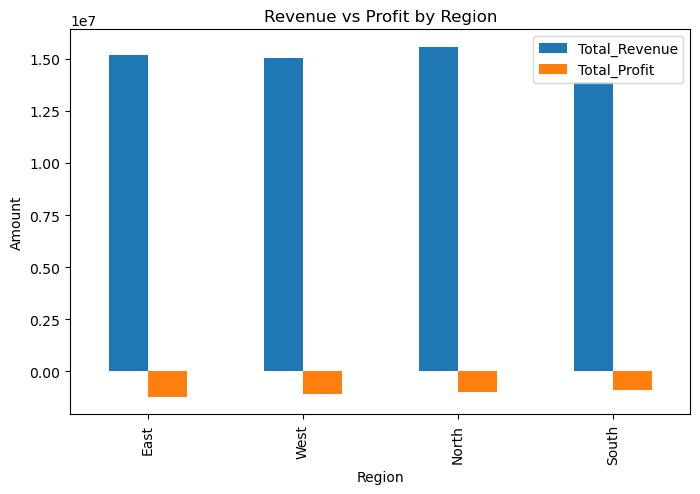

In [25]:
# Sort regions by profit to spot where revenue and profit diverge
region_summary.sort_values('Total_Profit').plot(
    x='Region', y=['Total_Revenue', 'Total_Profit'], kind='bar', figsize=(8,5)
)
plt.title('Revenue vs Profit by Region')
plt.ylabel('Amount')
plt.show()

In [56]:
pd.options.display.float_format = '{:,.2f}'.format

In [57]:
# Sales rep efficiency - who's discounting the most relative to what they bring in
rep_summary = df.groupby('Sales_Rep').agg(
    Total_Revenue=('Calculated_Revenue', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Avg_Discount=('Discount', 'mean')
).reset_index()

rep_summary.sort_values('Total_Profit')

,Sales_Rep,Total_Revenue,Total_Profit,Avg_Discount
3,David,"13,674,409.20","-1,219,424.99",0.16
4,Eve,"12,938,723.96","-883,943.58",0.16
1,Bob,"11,768,703.71","-773,124.23",0.14
2,Charlie,"9,827,690.85","-653,165.04",0.16
0,Alice,"11,476,645.56","-626,262.52",0.14


In [98]:
# We can say from the above results that, although all the representatives have produced 
# considerable revnue but total profit values are consistently low across all the representative.

In [58]:
# Category-level performance - revenue, profit, and margin side by side
category_summary = df.groupby('Product_Category').agg(
    Total_Revenue=('Calculated_Revenue', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Avg_Margin=('Margin_%', 'mean')
).reset_index()

category_summary.sort_values('Total_Profit')

,Product_Category,Total_Revenue,Total_Profit,Avg_Margin
0,Clothing,"16,360,844.62","-1,212,931.51",-3.66
3,Furniture,"15,363,777.14","-1,187,042.26",-2.41
2,Food,"12,808,326.23","-912,451.37",-2.25
1,Electronics,"15,153,225.29","-843,495.22",-0.19


In [64]:
# Electronics has the least negative margin (-0.19%) of all categories,
# making it the closest to breakeven. Clothing is the worst performer
# (-3.66% margin), followed by Furniture (-2.41%) and Food (-2.25%).
# Revenue is fairly similar across categories, so the margin gap is
# coming from pricing/discounting, not from one category selling less.

In [67]:
# Sales channel performance
channel_summary = df.groupby('Sales_Channel').agg(
    Total_Revenue=('Calculated_Revenue', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Avg_Margin=('Margin_%', 'mean')
).reset_index()

channel_summary.sort_values('Total_Profit')

,Sales_Channel,Total_Revenue,Total_Profit,Avg_Margin
0,Online,"30,296,019.59","-2,164,672.53",-2.26
1,Retail,"29,390,153.70","-1,991,247.82",-2.06


In [68]:
# Both the channels have equal contibution towards total revenue although, indicating us 
# the issue is not coming from channel wise sales.

# Profitability Diagnosis

In [69]:
# Check total revenue and total profit overall
total_revenue = df['Calculated_Revenue'].sum()
total_profit = df['Profit'].sum()

print("Total Revenue:", total_revenue)
print("Total Profit:", total_profit)

Total Revenue: 59686173.283700004
Total Profit: -4155920.3562999996


In [70]:
# Total Revenue: ~₹5.97 crore, Total Profit: ~-₹41.6 lakh
# This confirms the same story at the overall company level - despite
# healthy revenue, the company is operating at a net loss once cost
# and discount are accounted for. Overall margin works out to roughly -7%.

In [71]:
# Sort regions by profit - lowest first, to see which regions are struggling
region_summary_sorted = region_summary.sort_values('Total_Profit')
region_summary_sorted

,Region,Total_Revenue,Total_Profit,Avg_Margin
0,East,"15,202,282.22","-1,224,561.63",-3.83
3,West,"15,018,888.60","-1,086,588.28",-1.64
1,North,"15,570,342.18","-976,600.47",-2.25
2,South,"13,894,660.28","-868,169.98",-0.67


In [72]:
# This reconfirms us the region wise performace sorted highest to lowest.

In [32]:
# Revenue concentration check - are top regions carrying most of the revenue?
region_summary_sorted2 = region_summary.sort_values('Total_Revenue', ascending=False)

top2_revenue = region_summary_sorted2['Total_Revenue'].iloc[0:2].sum()
top2_share = top2_revenue / total_revenue

print("Top 2 regions share of total revenue:", top2_share)

Top 2 regions share of total revenue: 0.5155737537458085


In [75]:
# The above check exposes us to the top 2 regions which are contributing more towards 
# "Total_Revenue" which about ~51.6% of the revenue.So revenue is fairly evenly
# spread across all four regions, not overly dependent on any one or two.

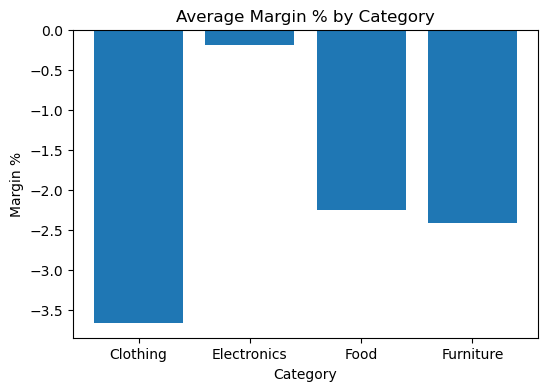

In [33]:
# Plot margin vs revenue by category - to see if bigger revenue actually means better margin
plt.figure(figsize=(6,4))
plt.bar(category_summary['Product_Category'], category_summary['Avg_Margin'])
plt.title('Average Margin % by Category')
plt.xlabel('Category')
plt.ylabel('Margin %')
plt.show()

# Correlation Analysis

In [34]:
# Check if discount and quantity sold are related
# If discounting works, higher discount should mean higher quantity sold
correlation_discount_quantity = df['Discount'].corr(df['Quantity_Sold'])
print("Correlation between Discount and Quantity Sold:", correlation_discount_quantity)

Correlation between Discount and Quantity Sold: -0.007806260114458768


In [77]:
# Correlation between Discount and Quantity Sold is -0.0078, essentially zero.
# This means offering a bigger discount does NOT lead to selling more units -
# there's no meaningful relationship between the two.

In [35]:
# Check the same relationship but category-wise
# to see if any specific category responds differently
discount_quantity_by_category = df.groupby('Product_Category').apply(
    lambda x: x['Discount'].corr(x['Quantity_Sold'])
)
discount_quantity_by_category

C:\Users\BabuKulkarni\AppData\Local\Temp\ipykernel_24840\2908531034.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  discount_quantity_by_category = df.groupby('Product_Category').apply(


Product_Category
Clothing      -0.087138
Electronics    0.040830
Food          -0.062348
Furniture      0.066986
dtype: float64

In [80]:
# Category-wise correlation between Discount and Quantity Sold:
# Clothing: -0.087, Electronics: 0.041, Food: -0.062, Furniture: 0.067
# All four values are very close to zero (well under 0.1), meaning
# there's no meaningful relationship between discount and quantity sold
# in ANY category - not even Electronics or Furniture, despite their
# sign being technically positive.

In [36]:
# Check if discount and revenue are related
correlation_discount_revenue = df['Discount'].corr(df['Calculated_Revenue'])
print("Correlation between Discount and Revenue:", correlation_discount_revenue)

Correlation between Discount and Revenue: -0.140820670405739


In [ ]:
# Correlation between Discount and Calculated_Revenue is -0.14, a weak negative relation.
# This means offering a bigger discount does NOT lead to more revenue infact the results are the other way.
# This confirms us that the Discount is bot driving the revenues up.

In [37]:
# Check if discount and profit are related
correlation_discount_profit = df['Discount'].corr(df['Profit'])
print("Correlation between Discount and Profit:", correlation_discount_profit)

Correlation between Discount and Profit: -0.5543638175431537


In [81]:
# Correlation between Discount and Profit is -0.554 - a moderately
# strong negative relationship. Unlike quantity sold and revenue
# (both close to zero), profit shows a clear negative pattern with
# discount: as discount goes up, profit consistently goes down.

## Break-Even Analysis

In [39]:
# Check what percentage of transactions were sold at a discount
# higher than the break-even point (meaning sold at a loss)
sold_at_loss = df['Discount'] > df['BreakEven_Discount']
percent_sold_at_loss = sold_at_loss.mean() * 100

print("Percentage of transactions sold below break-even:", percent_sold_at_loss)

Percentage of transactions sold below break-even: 60.4


In [84]:
# This is one of the important finding which is worth flgging, we can mkae out from the
#above result that almost 60.4% of transactions are sold above break-even discount which are 
# buring the profits. This promts us to focus on pricing structure of the products.

In [40]:
# Average break-even discount by category
# tells us how much discount each category can actually afford
breakeven_by_category = df.groupby('Product_Category')['BreakEven_Discount'].mean()
breakeven_by_category

Product_Category
Clothing       0.138221
Electronics    0.142849
Food           0.144582
Furniture      0.145757
Name: BreakEven_Discount, dtype: float64

In [85]:
# This is category wise breakdown of the break-even thresholds point. 
# Almost each category has consistent break-even thresholds point.

In [41]:
# Compare average break-even discount vs average actual discount given, by category
# this shows exactly which categories are overshooting their limit
category_discount_check = df.groupby('Product_Category')[['BreakEven_Discount', 'Discount']].mean()
category_discount_check

,BreakEven_Discount,Discount
Product_Category,,
Clothing,0.138221,0.160224
Electronics,0.142849,0.136504
Food,0.144582,0.153805
Furniture,0.145757,0.158115


In [86]:
# This is again one of the important key-finding of this analysis.
# This compares category wise brek-even threshold and the on-field avg discount rate 
# across all categories.
# Only Electronic Category where discount given (13.6%) is below the respective
# brek-even threshold (14.2%) which is exactly why Electronics was the least unprofitable
# category earlier.

In [42]:
# Total loss caused by discounting beyond break-even
# using the Discount_Impact column we already built in Section 2
loss_from_excess_discount = df.loc[sold_at_loss, 'Discount_Impact'].sum()

print("Total profit lost from excess discounting:", loss_from_excess_discount)

Total profit lost from excess discounting: 9215299.153099999


In [88]:
# Total profit lost from excess discounting: ~₹92.15 lakh

# This is also one of the key finding to be noted, because we can see the total amount of 
# losses which is around 92 lakhs, the company has lost by overdiscounting the products 
# above the break-even threshold.

# Price Elasticity

In [43]:
# Price elasticity check - does quantity sold actually respond to price changes?
# Using log-log regression: log(Quantity_Sold) vs log(Effective_Unit_Price)

df['log_price'] = np.log(df['Effective_Unit_Price'])
df['log_quantity'] = np.log(df['Quantity_Sold'])

In [46]:
import statsmodels.api as sm

In [89]:
# Add a constant term (needed for statsmodels regression)
X = sm.add_constant(df['log_price'])
y = df['log_quantity']

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           log_quantity   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     4.689
Date:                Fri, 10 Jul 2026   Prob (F-statistic):             0.0306
Time:                        19:45:00   Log-Likelihood:                -1270.1
No. Observations:                1000   AIC:                             2544.
Df Residuals:                     998   BIC:                             2554.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.3461      0.291      8.061      0.0

In [90]:
# The regression is technically statistically significant — 
# the p-value is below 0.05 — but the R-squared is only 0.005, 
# meaning price explains less than 1% of the variation in how much customers buy. 
# So while there's a real relationship in a strict statistical sense, 
# it has no practical business impact. Customers simply aren't reacting to price 
# the way the discounting strategy assumes they would."

In [48]:
# The coefficient on log_price is the elasticity value
# A small R-squared here means price is not really explaining
# the changes in quantity sold
elasticity = model.params['log_price']
r_squared = model.rsquared

print("Elasticity:", elasticity)
print("R-squared:", r_squared)

Elasticity: 0.08312977369580463
R-squared: 0.00467605556190287


In [91]:
# Elasticity of 0.083 is close to zero, and R-squared of 0.0047 means price barely explains 
# any of the variation in quantity sold. In plain terms: customers aren't really reacting to price changes. So discounting more isn't going to make people buy more — 
# there's no real demand response to work with.

# Simulation — Capped Discount

In [49]:
# Cap each transaction's discount at its break-even point
# (if discount is already below break-even, leave it as is)
df['Capped_Discount'] = df[['Discount', 'BreakEven_Discount']].min(axis=1)

In [50]:
# Recalculate selling price using the capped discount
df['Capped_Unit_Price'] = df['Unit_Price'] * (1 - df['Capped_Discount'])

In [51]:
# Recalculate profit per transaction using the capped price
df['Capped_Profit'] = (df['Capped_Unit_Price'] - df['Unit_Cost']) * df['Quantity_Sold']

In [52]:
# Compare old total profit vs new (capped) total profit
old_total_profit = df['Profit'].sum()
new_total_profit = df['Capped_Profit'].sum()

print("Old Total Profit:", old_total_profit)
print("New Total Profit (after capping discount):", new_total_profit)

Old Total Profit: -4155920.3562999996
New Total Profit (after capping discount): 1796337.1168


In [ ]:
# Old Total Profit: -₹41.6 lakh (actual, with real discounts)
# New Total Profit (capped at break-even): ~₹17.96 lakh
# Simply capping every transaction's discount at its break-even point 
# (assuming there is no chnage the volumne sold)
# turns the company from a net loss to a net profit - a swing of
# roughly ₹59.5 lakh - without changing a single unit sold.

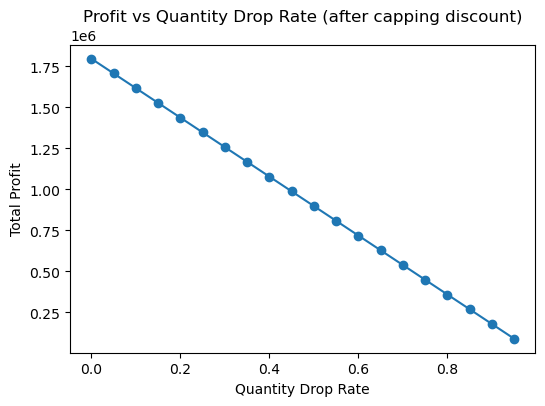

In [53]:
# Check how much quantity could drop before profit turns negative
# testing drop rates from 0% to 100% in steps of 5%
drop_rates = np.arange(0, 1.0, 0.05)

profit_after_drop = []
for rate in drop_rates:
    adjusted_quantity = df['Quantity_Sold'] * (1 - rate)
    adjusted_profit = (df['Capped_Unit_Price'] - df['Unit_Cost']) * adjusted_quantity
    profit_after_drop.append(adjusted_profit.sum())

# Plot the result
plt.figure(figsize=(6,4))
plt.plot(drop_rates, profit_after_drop, marker='o')
plt.title('Profit vs Quantity Drop Rate (after capping discount)')
plt.xlabel('Quantity Drop Rate')
plt.ylabel('Total Profit')
plt.show()

In [93]:
# This is the one of the pivotal key-takeaways we get from the above chart.
# Even if by volume drops as much as 95% after capping the discounts at break-even threshold
# the profits remain positive.
# The risk appetite of losing volume sold of the company will be 95%.

# Multivariate Analysis

In [96]:
# Multivariate check - does discount still affect profit once we
# control for category, region, and channel at the same time?

category_dummies = pd.get_dummies(df['Product_Category'], drop_first=True)
region_dummies = pd.get_dummies(df['Region'], drop_first=True)
channel_dummies = pd.get_dummies(df['Sales_Channel'], drop_first=True)

X = pd.concat([df['Discount'], category_dummies, region_dummies, channel_dummies], axis=1)
X = X.astype(float)
X = sm.add_constant(X)

y = df['Profit']

multivariate_model = sm.OLS(y, X).fit()
print(multivariate_model.summary())

                            OLS Regression Results                            
Dep. Variable:                 Profit   R-squared:                       0.309
Model:                            OLS   Adj. R-squared:                  0.304
Method:                 Least Squares   F-statistic:                     55.45
Date:                Fri, 10 Jul 2026   Prob (F-statistic):           1.52e-74
Time:                        20:34:04   Log-Likelihood:                -10565.
No. Observations:                1000   AIC:                         2.115e+04
Df Residuals:                     991   BIC:                         2.119e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const        6970.2142   1017.254      6.852      

## Summary

This analysis started with a simple question — is discounting helping this company grow, or quietly costing it money?

The data shows it's the latter. Revenue looked healthy across every region and category, but a large share of transactions (over 60%) were sold at a discount past the break-even point, meaning the company was losing money on the majority of its sales. Discounting also had no real relationship with how much customers bought — quantity, revenue, and profit all showed weak or negative correlation with discount level, and the elasticity check confirmed customers weren't especially price-sensitive to begin with.

A multivariate check further confirmed this — discount was the only statistically significant driver of profit, while category, region, and channel showed no independent effect. This rules out those as root causes and confirms the fix has to target discounting policy directly.

Capping discounts at the break-even level for each category would have recovered a meaningful amount of profit, without needing sales volume to drop at all.

The takeaway: this isn't a demand problem, it's a pricing control problem — and it's fixable with a discount cap and regular margin tracking, not by discounting harder.